In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

COLORS = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990",
]
NOISE_COLOR = "#aaaaaa"

print("All imports loaded.")

All imports loaded.


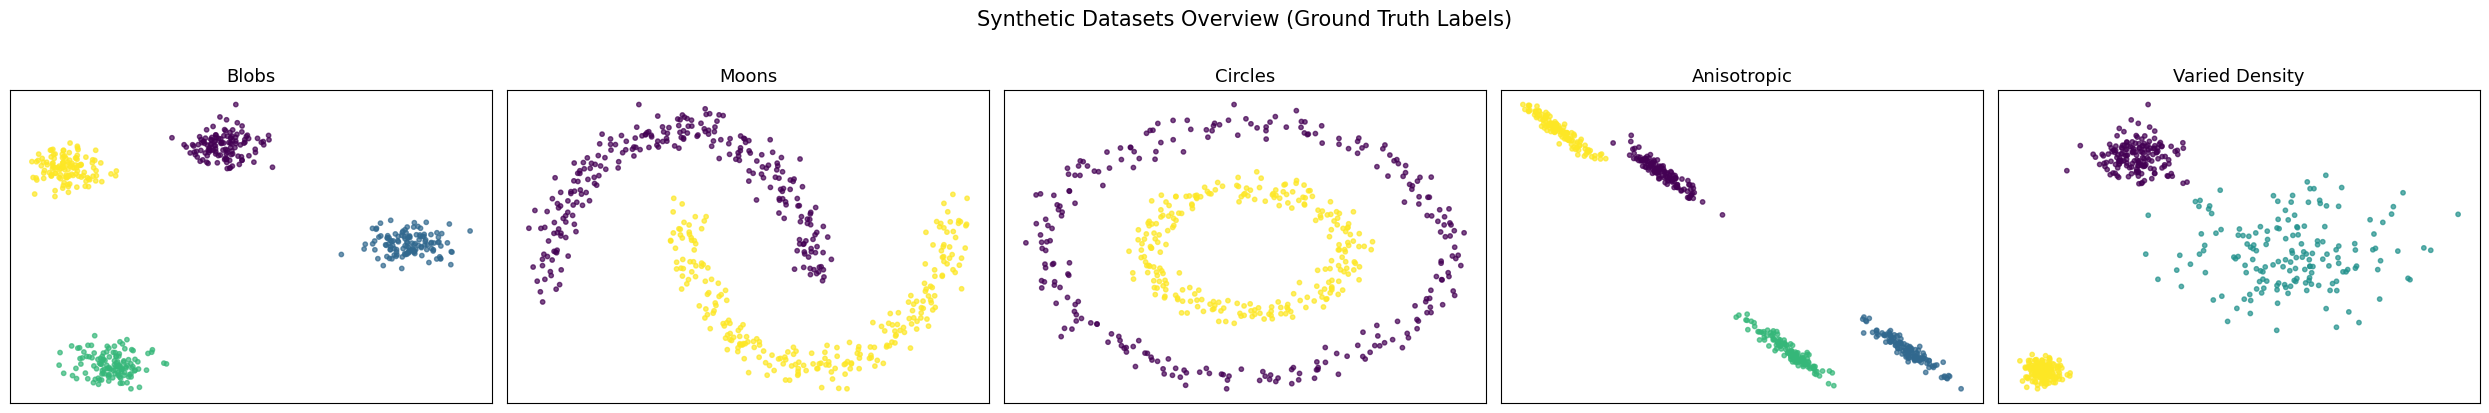

In [2]:
def generate_all_datasets():
    """Generate a dictionary of synthetic datasets with varying cluster geometry."""
    datasets = {}

    # (num_samples, num_features) — isotropic Gaussian blobs
    X_blobs, y_blobs = make_blobs(
        n_samples=500, centers=4, cluster_std=0.8, random_state=42
    )
    datasets["Blobs"] = (X_blobs, y_blobs)

    # (num_samples, 2) — interleaving half-moons
    X_moons, y_moons = make_moons(n_samples=500, noise=0.07, random_state=42)
    datasets["Moons"] = (X_moons, y_moons)

    # (num_samples, 2) — concentric circles
    X_circles, y_circles = make_circles(
        n_samples=500, factor=0.5, noise=0.05, random_state=42
    )
    datasets["Circles"] = (X_circles, y_circles)

    # Anisotropic (elongated) blobs via linear transformation
    transformation = np.array([[0.6, -0.6], [-0.4, 0.8]])
    # (num_samples, 2) @ (2, 2) → (num_samples, 2)
    X_aniso = X_blobs @ transformation
    datasets["Anisotropic"] = (X_aniso, y_blobs)

    # Varying density: three blobs with different std
    X_varied, y_varied = make_blobs(
        n_samples=500, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=42
    )
    datasets["Varied Density"] = (X_varied, y_varied)

    return datasets


ALL_DATASETS = generate_all_datasets()

fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for ax, (name, (X, y)) in zip(axes, ALL_DATASETS.items()):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", s=10, alpha=0.7)
    ax.set_title(name, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Synthetic Datasets Overview (Ground Truth Labels)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# 1) K-Means Clustering

## 1.1 Algorithm and Objective Function

K-Means is the canonical partitional clustering algorithm. It seeks to partition $n$ observations into $k$ non-overlapping clusters by minimizing the total **within-cluster sum of squares (WCSS)**, also called **inertia**.

**When to use:** The data forms roughly convex, isotropic clusters of similar size. K-Means excels on large datasets thanks to its $O(n \cdot k \cdot d \cdot T)$ time complexity, where $T$ is the number of iterations.

### Pros & Cons

| Pros | Cons |
|------|------|
| Simple, fast, scalable | Must specify $k$ a priori |
| Guaranteed convergence | Sensitive to initialization |
| Works well on spherical clusters | Fails on non-convex shapes |
| Linear time complexity | Sensitive to outliers |

In [3]:
class KMeans:
    """K-Means clustering with random or K-Means++ initialization.

    Minimizes WCSS via alternating assignment and centroid update.
    """

    def __init__(self, num_clusters=3, max_iter=300, tol=1e-6, init="random", random_state=42):
        self.num_clusters = num_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.init = init
        self.rng = np.random.RandomState(random_state)
        self.centroids = None
        self.labels = None
        self.inertia_ = None
        self.n_iter_ = 0

    def _init_centroids(self, X):
        """Initialize centroids using random selection or K-Means++."""
        num_samples = X.shape[0]

        if self.init == "random":
            indices = self.rng.choice(num_samples, self.num_clusters, replace=False)
            # (num_clusters, num_features)
            return X[indices].copy()

        elif self.init == "kmeans++":
            # (num_clusters, num_features)
            centroids = np.empty((self.num_clusters, X.shape[1]))

            # Pick first centroid uniformly at random
            first_idx = self.rng.randint(0, num_samples)
            centroids[0] = X[first_idx]

            for c in range(1, self.num_clusters):

                # squared distance to nearest existing centroid
                # (num_samples,)
                dists = np.min(
                    np.sum((X[:, np.newaxis, :] - centroids[np.newaxis, :c, :]) ** 2, axis=2),
                    axis=1,
                )

                # Probability proportional to D^2
                # To choose further point (higher probability)
                probs = dists / dists.sum()
                centroids[c] = X[self.rng.choice(num_samples, p=probs)]

            return centroids

        raise ValueError(f"Unknown init method: {self.init}")

    def _compute_distances(self, X):
        """Compute squared Euclidean distances from each point to each centroid."""
        # Input: (num_samples, 1, num_features) - (1, num_clusters, num_features)
        # Output: (num_samples, num_clusters)
        diff = X[:, np.newaxis, :] - self.centroids[np.newaxis, :, :]
        return np.sum(diff ** 2, axis=2)

    def _assign_clusters(self, X):
        """Assign each point to the nearest centroid."""
        # (num_samples, num_clusters) → (num_samples,)
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        """Recompute centroids as cluster means."""
        # (num_clusters, num_features)
        new_centroids = np.zeros((self.num_clusters, X.shape[1]))
        for j in range(self.num_clusters):
            members = X[labels == j]
            if len(members) > 0:
                new_centroids[j] = members.mean(axis=0)
            else:
                # Reinitialize dead centroid to a random point
                new_centroids[j] = X[self.rng.randint(0, X.shape[0])]
        return new_centroids

    def fit(self, X):
        """Run K-Means until convergence or max_iter."""
        self.centroids = self._init_centroids(X)

        for iteration in range(self.max_iter):
            self.labels = self._assign_clusters(X)
            new_centroids = self._update_centroids(X, self.labels)

            # Convergence check: max centroid shift
            shift = np.max(np.sqrt(np.sum((new_centroids - self.centroids) ** 2, axis=1)))
            self.centroids = new_centroids
            self.n_iter_ = iteration + 1

            if shift < self.tol:
                break

        # Final inertia
        distances = self._compute_distances(X)
        # sum of square distance to cluster centre
        self.inertia_ = np.sum(distances[np.arange(len(X)), self.labels])
        return self

    def predict(self, X):
        """Assign new points to the nearest centroid."""
        return self._assign_clusters(X)


print("KMeans class defined.")

KMeans class defined.


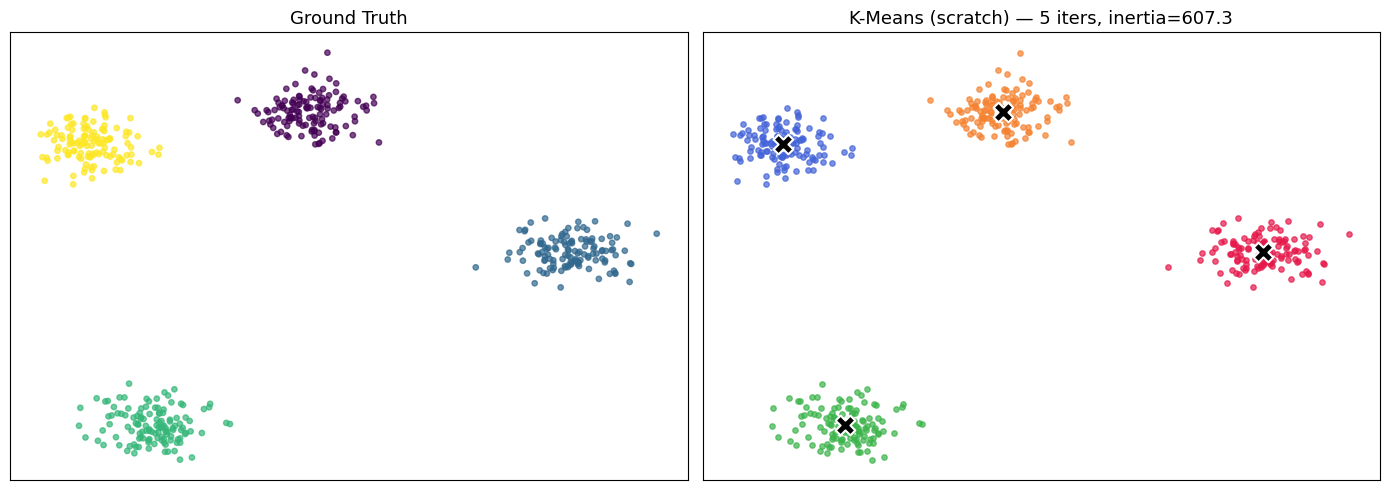

In [4]:
# Demonstrate K-Means from scratch on blobs dataset
X_blobs, y_blobs = ALL_DATASETS["Blobs"]

km_scratch = KMeans(num_clusters=4, init="random", random_state=42)
km_scratch.fit(X_blobs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ground truth
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap="viridis", s=15, alpha=0.7)
axes[0].set_title("Ground Truth", fontsize=13)

# K-Means result with centroid markers
for j in range(km_scratch.num_clusters):
    mask = km_scratch.labels == j
    axes[1].scatter(X_blobs[mask, 0], X_blobs[mask, 1], c=COLORS[j], s=15, alpha=0.7)
axes[1].scatter(
    km_scratch.centroids[:, 0], km_scratch.centroids[:, 1],
    c="black", marker="X", s=200, edgecolors="white", linewidths=1.5, zorder=5,
)
axes[1].set_title(
    f"K-Means (scratch) — {km_scratch.n_iter_} iters, inertia={km_scratch.inertia_:.1f}",
    fontsize=13,
)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 1.2 Elbow Method and Silhouette Analysis

Choosing $k$ is the central practical challenge of K-Means.

- Elbow Method
Plot inertia (WCSS) vs. $k$. The "elbow" — the point of diminishing returns — suggests the natural number of clusters. Formally, we look for the $k$ where the second derivative $\Delta^2 J(k)$ is maximized.

- Silhouette Score
For each point $i$:
    - $a(i)$ = mean intra-cluster distance
    - $b(i)$ = mean distance to the nearest neighboring cluster

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} \in [-1, 1]
$$

A score near $+1$ indicates a well-clustered point; near $0$ means it lies on a boundary; near $-1$ means likely misassigned.

In [8]:
def silhouette_score(X, labels):
    """Compute the mean Silhouette Coefficient of all samples from scratch."""
    num_samples = X.shape[0]
    unique_labels = np.unique(labels)

    # If there is only 1 cluster or each point is its own cluster, score is 0
    if len(unique_labels) <= 1 or len(unique_labels) == num_samples:
        return 0.0

    # Precompute pairwise distance matrix
    dist_matrix = squareform(pdist(X, metric="euclidean"))
    s_vals = np.zeros(num_samples)

    for i in range(num_samples):
        label_i = labels[i]

        # a(i): mean intra-cluster distance
        same_cluster_mask = (labels == label_i)
        cluster_size = np.sum(same_cluster_mask)

        if cluster_size > 1:
            # Get the distance sum of similar cluster
            # Subtract 1 from denominator to exclude the point itself (distance is 0)
            a_i = np.sum(dist_matrix[i, same_cluster_mask]) / (cluster_size - 1)
        else:
            # If cluster has only one point, silhouette score is formally 0
            s_vals[i] = 0.0
            continue

        # b(i): mean distance to the nearest neighboring cluster
        b_i = np.inf
        for other_label in unique_labels:
            if other_label == label_i:
                continue
            other_cluster_mask = (labels == other_label)
            avg_dist_to_other = np.mean(dist_matrix[i, other_cluster_mask])
            if avg_dist_to_other < b_i:
                b_i = avg_dist_to_other

        # s(i) calculation
        s_vals[i] = (b_i - a_i) / max(a_i, b_i)

    return np.mean(s_vals)

# Quick test to compare against sklearn
_score = silhouette_score(X_blobs, km_scratch.labels)
print(f"Scratch Silhouette Score: {_score:.4f}")

Scratch Silhouette Score: 0.8336


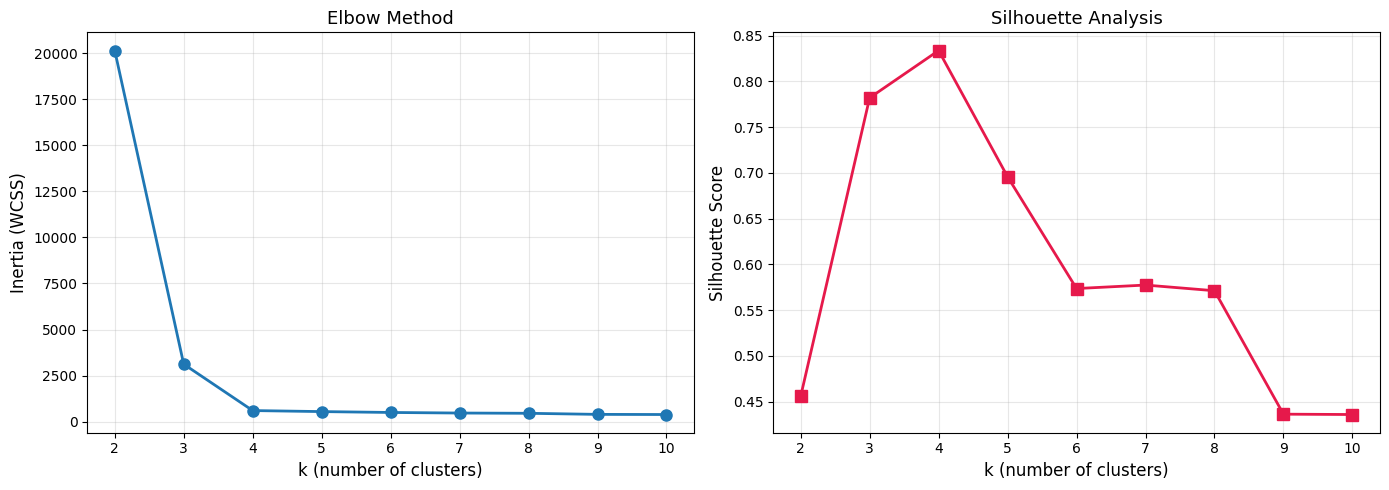

Best k by silhouette score: 4 (score=0.8336)


In [10]:
# Elbow method and silhouette analysis
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(num_clusters=k, init="kmeans++", random_state=42)
    km.fit(X_blobs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_blobs, km.labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, "o-", linewidth=2, markersize=8)
axes[0].set_xlabel("k (number of clusters)", fontsize=12)
axes[0].set_ylabel("Inertia (WCSS)", fontsize=12)
axes[0].set_title("Elbow Method", fontsize=13)
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, "s-", linewidth=2, markersize=8, color="#e6194b")
axes[1].set_xlabel("k (number of clusters)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=12)
axes[1].set_title("Silhouette Analysis", fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"Best k by silhouette score: {best_k} (score={max(silhouettes):.4f})")

## 1.3 K-Means++ Initialization

Random initialization can lead to arbitrarily poor local minima. **K-Means++** (Arthur & Vassilvitskii, 2007) provides a principled initialization that guarantees $O(\log k)$-competitive expected cost compared to the optimal solution.

### Algorithm

1. Choose the first centroid $\mu_1$ uniformly at random from $X$.
2. For each subsequent centroid $\mu_c$, sample a point $\mathbf{x}_i$ with probability proportional to $D(\mathbf{x}_i)^2$, where $D(\mathbf{x}_i)$ is the distance from $\mathbf{x}_i$ to the nearest existing centroid.
3. Repeat until $k$ centroids are chosen.

This spreads initial centroids apart, making convergence to a better local minimum far more likely.

Our `KMeansScratch` class above already implements this (set `init="kmeans++"`).

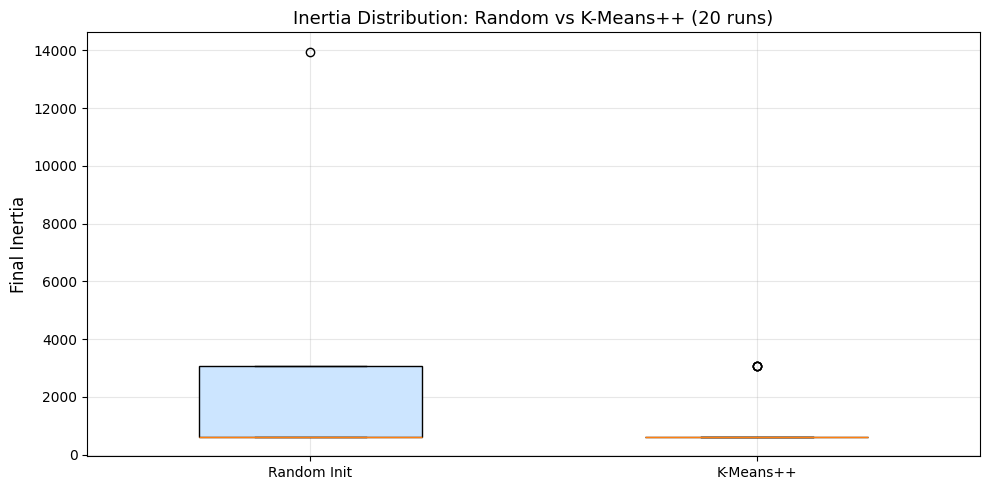

Random — mean inertia: 2259.13, std: 2933.49
KM++   — mean inertia: 1099.16, std: 983.73


In [ ]:
# Compare random vs K-Means++ initialization over multiple runs
num_runs = 20
random_inertias = []
pp_inertias = []

for seed in range(num_runs):
    km_r = KMeans(num_clusters=4, init="random", random_state=seed)
    km_r.fit(X_blobs)
    random_inertias.append(km_r.inertia_)

    km_pp = KMeans(num_clusters=4, init="kmeans++", random_state=seed)
    km_pp.fit(X_blobs)
    pp_inertias.append(km_pp.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    [random_inertias, pp_inertias],
    labels=["Random Init", "K-Means++"],
    widths=0.5,
    patch_artist=True,
    boxprops=dict(facecolor="#cce5ff"),
)
ax.set_ylabel("Final Inertia", fontsize=12)
ax.set_title("Inertia Distribution: Random vs K-Means++ (20 runs)", fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Random — mean inertia: {np.mean(random_inertias):.2f}, std: {np.std(random_inertias):.2f}")
print(f"KM++   — mean inertia: {np.mean(pp_inertias):.2f}, std: {np.std(pp_inertias):.2f}")

## 1.4 Comparison with sklearn

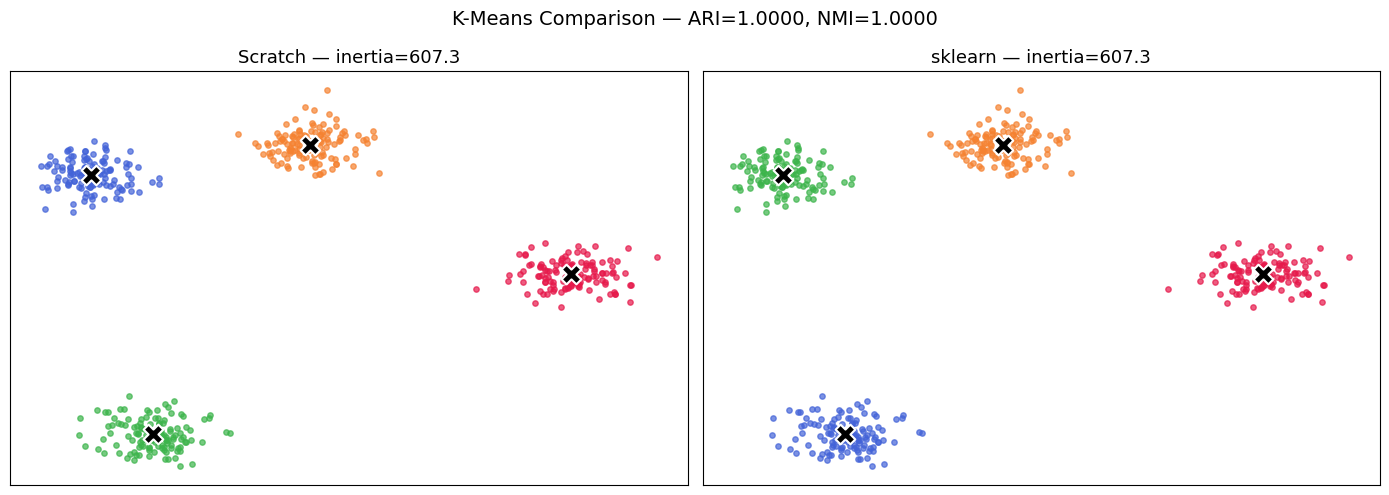

Scratch iterations: 2, sklearn iterations: 2
Adjusted Rand Index: 1.0000
Normalized Mutual Information: 1.0000


In [ ]:
# Compare our scratch implementation against sklearn's KMeans
from sklearn.cluster import KMeans as SklearnKMeans

km_ours = KMeans(num_clusters=4, init="kmeans++", random_state=42)
km_ours.fit(X_blobs)

km_sk = SklearnKMeans(n_clusters=4, init="k-means++", random_state=42, n_init=1)
km_sk.fit(X_blobs)

ari = adjusted_rand_score(km_ours.labels, km_sk.labels_)
nmi = normalized_mutual_info_score(km_ours.labels, km_sk.labels_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j in range(4):
    mask_ours = km_ours.labels == j
    axes[0].scatter(X_blobs[mask_ours, 0], X_blobs[mask_ours, 1], c=COLORS[j], s=15, alpha=0.7)
axes[0].scatter(
    km_ours.centroids[:, 0], km_ours.centroids[:, 1],
    c="black", marker="X", s=200, edgecolors="white", linewidths=1.5, zorder=5,
)
axes[0].set_title(f"Scratch — inertia={km_ours.inertia_:.1f}", fontsize=13)

for j in range(4):
    mask_sk = km_sk.labels_ == j
    axes[1].scatter(X_blobs[mask_sk, 0], X_blobs[mask_sk, 1], c=COLORS[j], s=15, alpha=0.7)
axes[1].scatter(
    km_sk.cluster_centers_[:, 0], km_sk.cluster_centers_[:, 1],
    c="black", marker="X", s=200, edgecolors="white", linewidths=1.5, zorder=5,
)
axes[1].set_title(f"sklearn — inertia={km_sk.inertia_:.1f}", fontsize=13)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(f"K-Means Comparison — ARI={ari:.4f}, NMI={nmi:.4f}", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Scratch iterations: {km_ours.n_iter_}, sklearn iterations: {km_sk.n_iter_}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")

---
# 2) DBSCAN

DBSCAN (Ester et al., 1996) is a **density-based** clustering algorithm that groups together regions of high point density separated by regions of low density. Unlike K-Means, it does not require specifying the number of clusters, can find **arbitrarily shaped** clusters, and has a built-in concept of **noise** (outliers).

**When to use:** Data has clusters of arbitrary shape, varying density boundaries, or contains significant noise/outliers.

| Pros | Cons |
|------|------|
| No need to specify $k$ | Sensitive to $\varepsilon$ and MinPts |
| Finds arbitrary-shape clusters | Struggles with varying density |
| Robust to outliers (labels noise) | $O(n^2)$ without spatial index |
| Deterministic (unlike K-Means) | High-dimensional data degrades distance |

## 2.1 Implementation

Put it in the exact terms of the algorithm:

1. Start from a point: It finds a "core point" (a point with enough dense neighbors).
2. Find its neighbors: It grabs all the neighbors within that close distance (eps).
3. Neighbor's neighbors: If those neighbors are also core points, it grabs their neighbors too (the while seed_set: loop).
4. Pull it all together: It keeps chaining this out like a spreading puddle of water until it hits the "edges" (border points that don't have enough neighbors to keep spreading). Everything the puddle touched becomes one single cluster.
5. Any points left completely dry at the end (no core points ever reached them) are labeled as outliers/noise.

In [ ]:
class DBSCAN:
    """DBSCAN via naive O(n^2) pairwise distance approach.

    Identifies core, border, and noise points using eps-neighborhood density.
    """

    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels = None
        self.core_mask = None

    def fit(self, X):
        num_samples = X.shape[0]

        # Compute the full pairwise Euclidean distance matrix
        # Resulting shape: (num_samples, num_samples)
        dist_matrix = squareform(pdist(X, metric="euclidean"))

        # Precompute neighborhoods
        # each sample has a list of arrays (diff length)
        # eps is actually the maximum distance threshold
        neighborhoods = [
            np.where(dist_matrix[i] <= self.eps)[0] for i in range(num_samples)
        ]

        # Identify core points: a point is a core point if its neighborhood size >= min_samples
        # (num_samples,)
        self.core_mask = np.array(
            [len(neighborhoods[i]) >= self.min_samples for i in range(num_samples)]
        )

        # Initialize all labels to -1 (which represents noise/unassigned)
        self.labels = -np.ones(num_samples, dtype=int)
        cluster_id = 0

        # Iterate through all points to find unvisited core points and expand clusters
        for i in range(num_samples):

            # If the point is already assigned to a cluster or is not a core point, skip it
            if self.labels[i] != -1 or not self.core_mask[i]:
                continue

            # Start a new cluster from the unvisited core point `i`
            self.labels[i] = cluster_id

            # Initialize the seed set with the core point's neighbors
            # (excluding the point itself)
            seed_set = set(neighborhoods[i]) - {i}

            # Breadth-First Search (BFS) expansion
            # Target neighbor, and neighbor's neighbor
            while seed_set:
                q = seed_set.pop()

                # If `q` is also a core point, add its unvisited neighbors to the seed set
                if self.core_mask[q]:
                    new_neighbors = set(neighborhoods[q])
                    # Find neighbors that haven't been assigned to any cluster yet
                    unvisited = new_neighbors - set(np.where(self.labels != -1)[0])
                    # Union update
                    seed_set |= unvisited

                # Assign `q` to the current cluster if it hasn't been assigned yet
                # (It could be a border point or unvisited)
                if self.labels[q] == -1:
                    self.labels[q] = cluster_id

            # Increment cluster_id for the next core point
            cluster_id += 1

        return self

print("DBSCAN class defined.")

DBSCAN class defined.


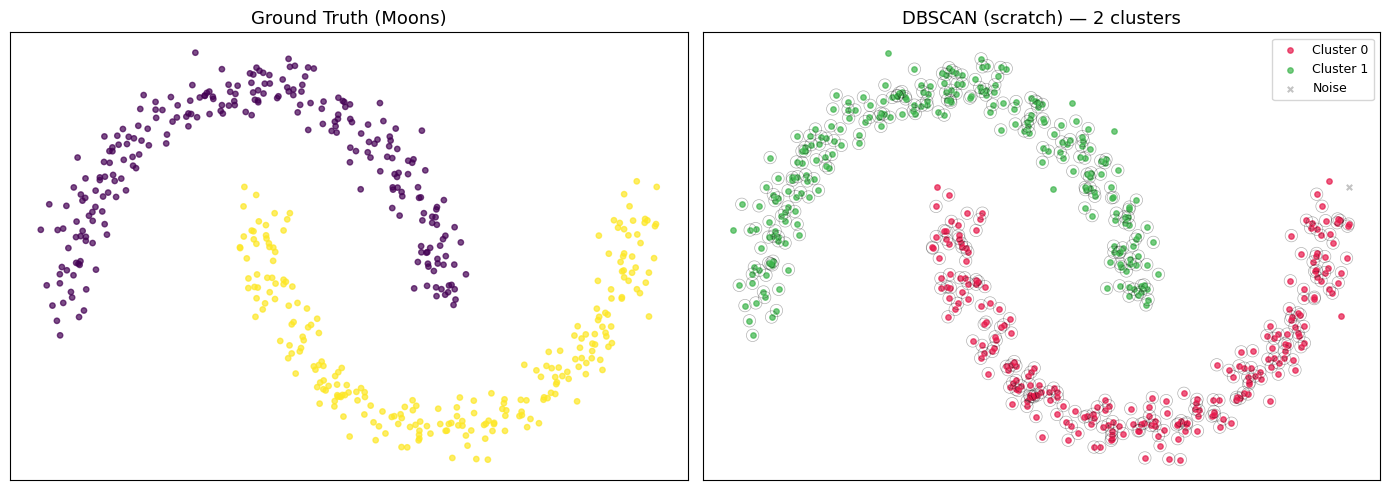

Core points: 491, Noise points: 1


In [ ]:
# Demonstrate DBSCAN on moons dataset (non-convex clusters)
X_moons, y_moons = ALL_DATASETS["Moons"]

db_scratch = DBSCAN(eps=0.15, min_samples=5)
db_scratch.fit(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="viridis", s=15, alpha=0.7)
axes[0].set_title("Ground Truth (Moons)", fontsize=13)

# Color clusters, noise in gray
unique_labels = set(db_scratch.labels)
for label in unique_labels:
    mask = db_scratch.labels == label
    color = NOISE_COLOR if label == -1 else COLORS[label % len(COLORS)]
    marker = "x" if label == -1 else "o"
    label_str = "Noise" if label == -1 else f"Cluster {label}"
    axes[1].scatter(X_moons[mask, 0], X_moons[mask, 1], c=color, s=15, alpha=0.7, marker=marker, label=label_str)

# Mark core points with larger markers
axes[1].scatter(
    X_moons[db_scratch.core_mask, 0], X_moons[db_scratch.core_mask, 1],
    facecolors="none", edgecolors="black", s=80, linewidths=0.5, alpha=0.3,
)
axes[1].set_title(f"DBSCAN (scratch) — {len(unique_labels - {-1})} clusters", fontsize=13)
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

n_noise = np.sum(db_scratch.labels == -1)
print(f"Core points: {np.sum(db_scratch.core_mask)}, Noise points: {n_noise}")

## 2.2 Parameter Selection (eps, min_samples)

- Choosing eps: k-Distance Graph
Plot the distance to the $k$-th nearest neighbor (sorted in descending order) for each point, where $k$ = `min_samples`. The "elbow" in this plot suggests a good $\varepsilon$ value. Points beyond the elbow are likely noise.

- Choosing min_samples
Rule of thumb: `min_samples` $\ge d + 1$ where $d$ is the dimensionality. For 2D data, `min_samples = 5` is a common starting point. Larger values produce more conservative clustering (fewer, denser clusters).

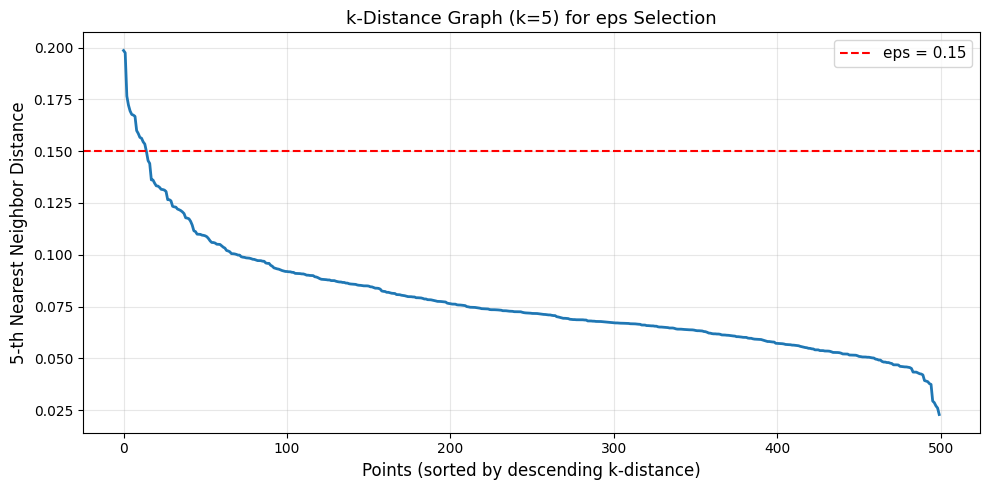

In [ ]:
# k-distance graph for choosing eps
k = 5

# (num_samples, num_samples)
dist_matrix = squareform(pdist(X_moons, metric="euclidean"))

# Sort distances for each point, take the k-th nearest
# (num_samples, num_samples) → sort each row → take column k
sorted_dists = np.sort(dist_matrix, axis=1)
# (num_samples,) — k-th nearest neighbor distance
k_dists = sorted_dists[:, k]

# Sort in descending order for the "elbow" plot
k_dists_sorted = np.sort(k_dists)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dists_sorted, linewidth=2)
ax.axhline(y=0.15, color="red", linestyle="--", label=f"eps = 0.15")
ax.set_xlabel("Points (sorted by descending k-distance)", fontsize=12)
ax.set_ylabel(f"{k}-th Nearest Neighbor Distance", fontsize=12)
ax.set_title(f"k-Distance Graph (k={k}) for eps Selection", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.5 Comparison with sklearn

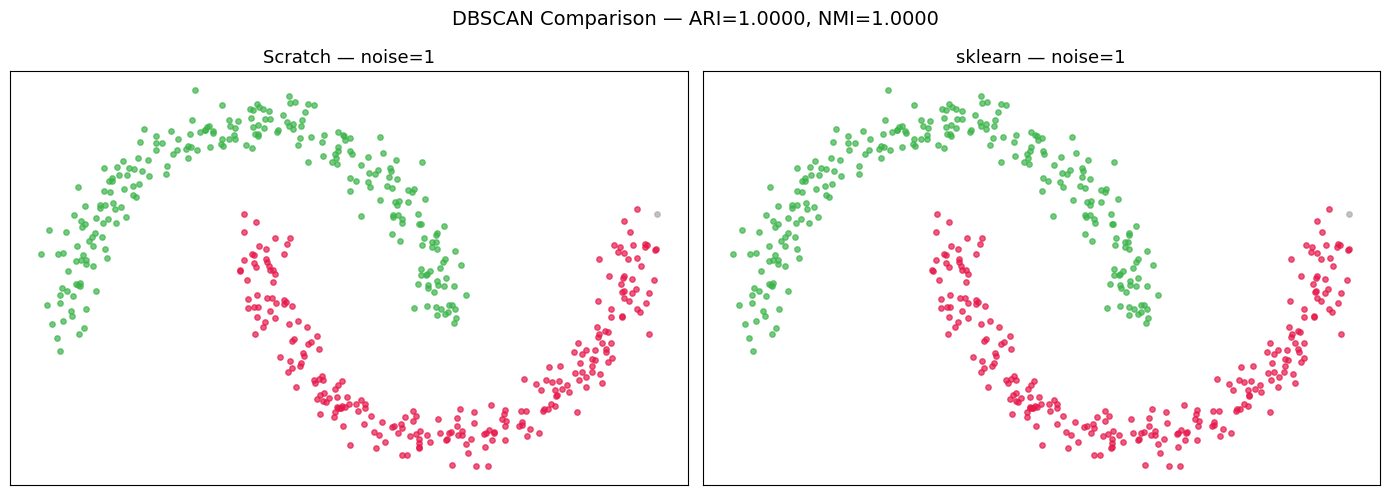

Adjusted Rand Index: 1.0000
Normalized Mutual Information: 1.0000


In [ ]:
# Compare scratch DBSCAN with sklearn
from sklearn.cluster import DBSCAN as SklearnDBSCAN

db_sk = SklearnDBSCAN(eps=0.15, min_samples=5)
db_sk.fit(X_moons)

ari = adjusted_rand_score(db_scratch.labels, db_sk.labels_)
nmi = normalized_mutual_info_score(db_scratch.labels, db_sk.labels_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in set(db_scratch.labels):
    mask = db_scratch.labels == label
    c = NOISE_COLOR if label == -1 else COLORS[label % len(COLORS)]
    axes[0].scatter(X_moons[mask, 0], X_moons[mask, 1], c=c, s=15, alpha=0.7)
axes[0].set_title(f"Scratch — noise={np.sum(db_scratch.labels == -1)}", fontsize=13)

for label in set(db_sk.labels_):
    mask = db_sk.labels_ == label
    c = NOISE_COLOR if label == -1 else COLORS[label % len(COLORS)]
    axes[1].scatter(X_moons[mask, 0], X_moons[mask, 1], c=c, s=15, alpha=0.7)
axes[1].set_title(f"sklearn — noise={np.sum(db_sk.labels_ == -1)}", fontsize=13)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(f"DBSCAN Comparison — ARI={ari:.4f}, NMI={nmi:.4f}", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")

---
# 3) Hierarchical Clustering (Agglomerative)

![](https://media.geeksforgeeks.org/wp-content/uploads/20250526124835454679/Types-of-Hierarchical-Clustering.webp)

Agglomerative hierarchical clustering builds a hierarchy of clusters **bottom-up**. Each point starts as its own cluster; at each step, the two "closest" clusters are merged. The result is a **dendrogram** — a tree that encodes the full nesting structure. Cutting the tree at a chosen height yields any desired number of clusters.

**When to use:** You want a hierarchy of cluster relationships, the number of clusters is unknown, or you need to visualize cluster structure at multiple granularities.

| Pros | Cons |
|------|------|
| No need to prespecify $k$ | $O(n^2)$ memory, $O(n^3)$ time |
| Full hierarchy via dendrogram | Merges are irreversible (greedy) |
| Multiple linkage options | Not suitable for very large $n$ |
| Deterministic | Sensitive to noise (single linkage) |

In [ ]:
class Agglomerative:
    """Agglomerative hierarchical clustering with multiple linkage methods.

    Builds a linkage matrix compatible with scipy's dendrogram function.
    Naive O(n^3) implementation for clarity.
    """

    LINKAGE_METHODS = ("single", "complete", "average", "ward")

    def __init__(self, num_clusters=2, linkage_method="ward"):
        # Set up the basic rules: how many clusters we want at the end,
        # and how we measure the distance between two groups (linkage).
        assert linkage_method in self.LINKAGE_METHODS
        self.num_clusters = num_clusters
        self.linkage_method = linkage_method
        self.labels = None
        self.linkage_matrix = None

    def _compute_cluster_distance(self, X, cluster_a, cluster_b):
        """Compute inter-cluster distance based on linkage method."""
        # Grab the actual coordinates for the points in Group A and Group B
        points_a = X[list(cluster_a)]
        points_b = X[list(cluster_b)]

        if self.linkage_method == "single":
            # Closest friends: find the absolute shortest distance between
            # ANY point in Group A and ANY point in Group B.
            dists = np.linalg.norm(
                points_a[:, np.newaxis, :] - points_b[np.newaxis, :, :], axis=2
            )
            return np.min(dists)

        elif self.linkage_method == "complete":
            # Farthest enemies: find the absolute longest distance between
            # ANY point in Group A and ANY point in Group B.
            dists = np.linalg.norm(
                points_a[:, np.newaxis, :] - points_b[np.newaxis, :, :], axis=2
            )
            return np.max(dists)

        elif self.linkage_method == "average":
            # Average Joe: calculate the distance between all pairs,
            # then just take the average.
            dists = np.linalg.norm(
                points_a[:, np.newaxis, :] - points_b[np.newaxis, :, :], axis=2
            )
            return np.mean(dists)

        elif self.linkage_method == "ward":
            # Center of gravity: Find the center of Group A and the center of Group B,
            # and measure the distance between those centers (adjusted by group sizes).
            mu_a = points_a.mean(axis=0)
            mu_b = points_b.mean(axis=0)
            na, nb = len(cluster_a), len(cluster_b)
            return np.sqrt(2.0 * na * nb / (na + nb)) * np.linalg.norm(mu_a - mu_b)

    def fit(self, X):
        num_samples = X.shape[0]

        # Every single data point starts as its own individual "cluster".
        clusters = {i: {i} for i in range(num_samples)}
        next_id = num_samples

        # keep record when two clusters merge so we can draw a tree later.
        linkage_rows = []

        # Keep merging until everyone is connected into one giant cluster.
        for step in range(num_samples - 1):
            active_ids = list(clusters.keys())
            if len(active_ids) <= 1:
                break

            # Look at EVERY possible pair of clusters to find the two that are closest together.
            best_dist = np.inf
            best_pair = None
            for idx_i in range(len(active_ids)):
                for idx_j in range(idx_i + 1, len(active_ids)):
                    cid_a = active_ids[idx_i]
                    cid_b = active_ids[idx_j]
                    d = self._compute_cluster_distance(X, clusters[cid_a], clusters[cid_b])
                    if d < best_dist:
                        best_dist = d
                        best_pair = (cid_a, cid_b)

            # Take the closest pair and combine their points.
            cid_a, cid_b = best_pair
            merged = clusters[cid_a] | clusters[cid_b]

            # Write down this event in our diary
            linkage_rows.append([cid_a, cid_b, best_dist, len(merged)])

            # Delete the two old clusters
            del clusters[cid_a]
            del clusters[cid_b]
            clusters[next_id] = merged
            next_id += 1

        # Save our diary so SciPy can draw the dendrogram (tree picture)
        self.linkage_matrix = np.array(linkage_rows)

        # don't want 1 giant cluster, we want `num_clusters`.
        self.labels = self._cut_tree(num_samples)
        return self

    def _cut_tree(self, num_samples):
        """Cut dendrogram to yield self.num_clusters clusters."""

        # We play back the tape of all our merges, but we STOP early
        cluster_map = {i: i for i in range(num_samples)}
        parent = {}

        num_merges_needed = num_samples - self.num_clusters

        for row_idx in range(num_merges_needed):
            cid_a = int(self.linkage_matrix[row_idx, 0])
            cid_b = int(self.linkage_matrix[row_idx, 1])
            new_id = num_samples + row_idx
            parent[cid_a] = new_id
            parent[cid_b] = new_id

        # Trace back the family tree for each point to see which of the final big clusters it belongs to.
        def find_root(node):
            while node in parent:
                node = parent[node]
            return node

        roots = [find_root(i) for i in range(num_samples)]
        unique_roots = list(set(roots))

        # Give each point its final group label (0, 1, 2, etc.)
        labels = np.array([unique_roots.index(r) for r in roots])
        return labels


print("Agglomerative class defined.")

Agglomerative class defined.


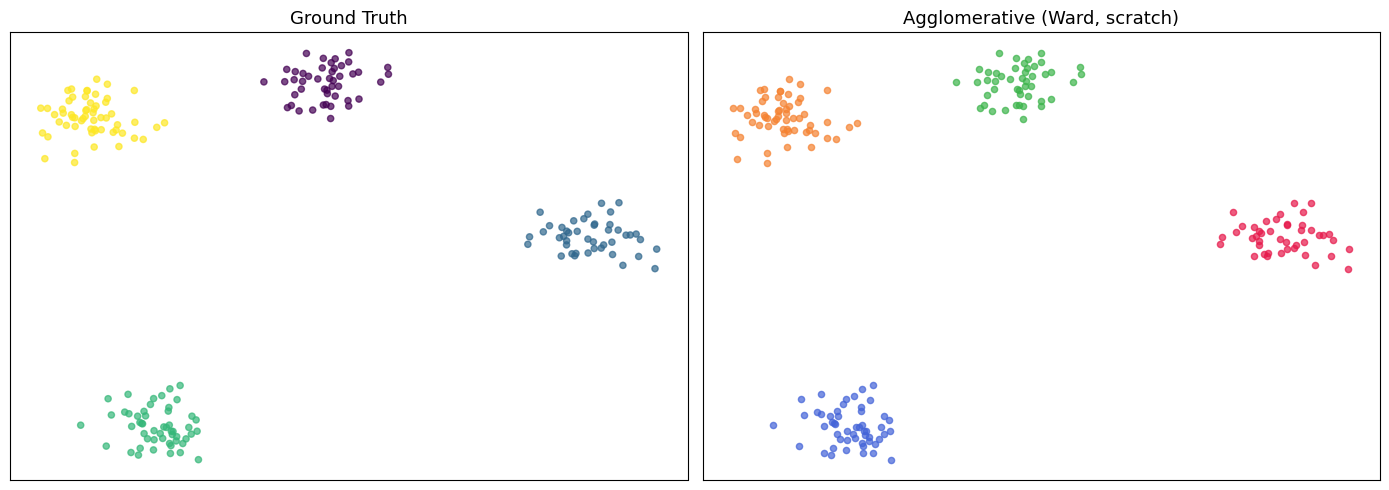

In [ ]:
# Demonstrate agglomerative clustering on blobs (subset for speed)
X_agg = X_blobs[:200]
y_agg = y_blobs[:200]

agg_scratch = Agglomerative(num_clusters=4, linkage_method="ward")
agg_scratch.fit(X_agg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_agg[:, 0], X_agg[:, 1], c=y_agg, cmap="viridis", s=20, alpha=0.7)
axes[0].set_title("Ground Truth", fontsize=13)

for j in range(4):
    mask = agg_scratch.labels == j
    axes[1].scatter(X_agg[mask, 0], X_agg[mask, 1], c=COLORS[j], s=20, alpha=0.7)
axes[1].set_title(f"Agglomerative (Ward, scratch)", fontsize=13)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

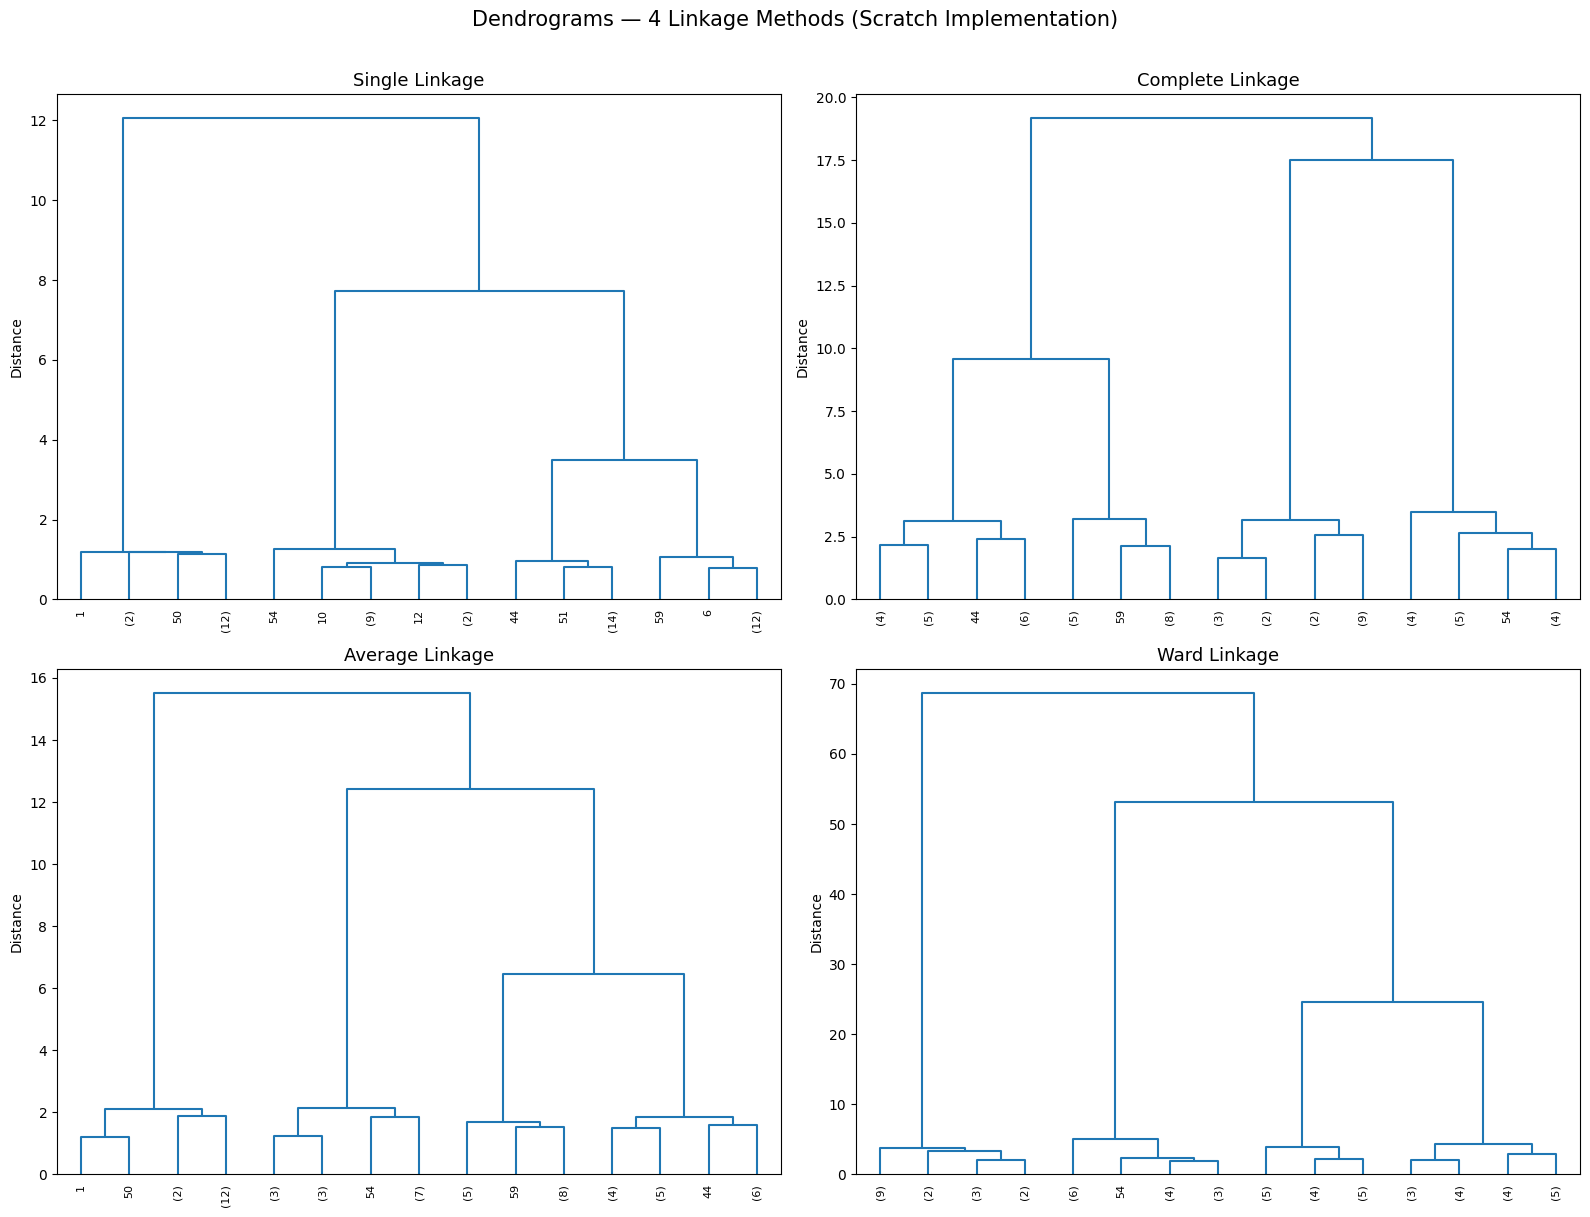

In [ ]:
# Dendrogram using our scratch linkage matrix
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subset for readable dendrogram
X_dendro = X_blobs[:60]

for ax, method in zip(axes.flat, ["single", "complete", "average", "ward"]):
    agg = Agglomerative(num_clusters=4, linkage_method=method)
    agg.fit(X_dendro)

    dendrogram(
        agg.linkage_matrix,
        ax=ax,
        truncate_mode="lastp",
        p=15,
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=0,
    )
    ax.set_title(f"{method.capitalize()} Linkage", fontsize=13)
    ax.set_ylabel("Distance", fontsize=10)

plt.suptitle("Dendrograms — 4 Linkage Methods (Scratch Implementation)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

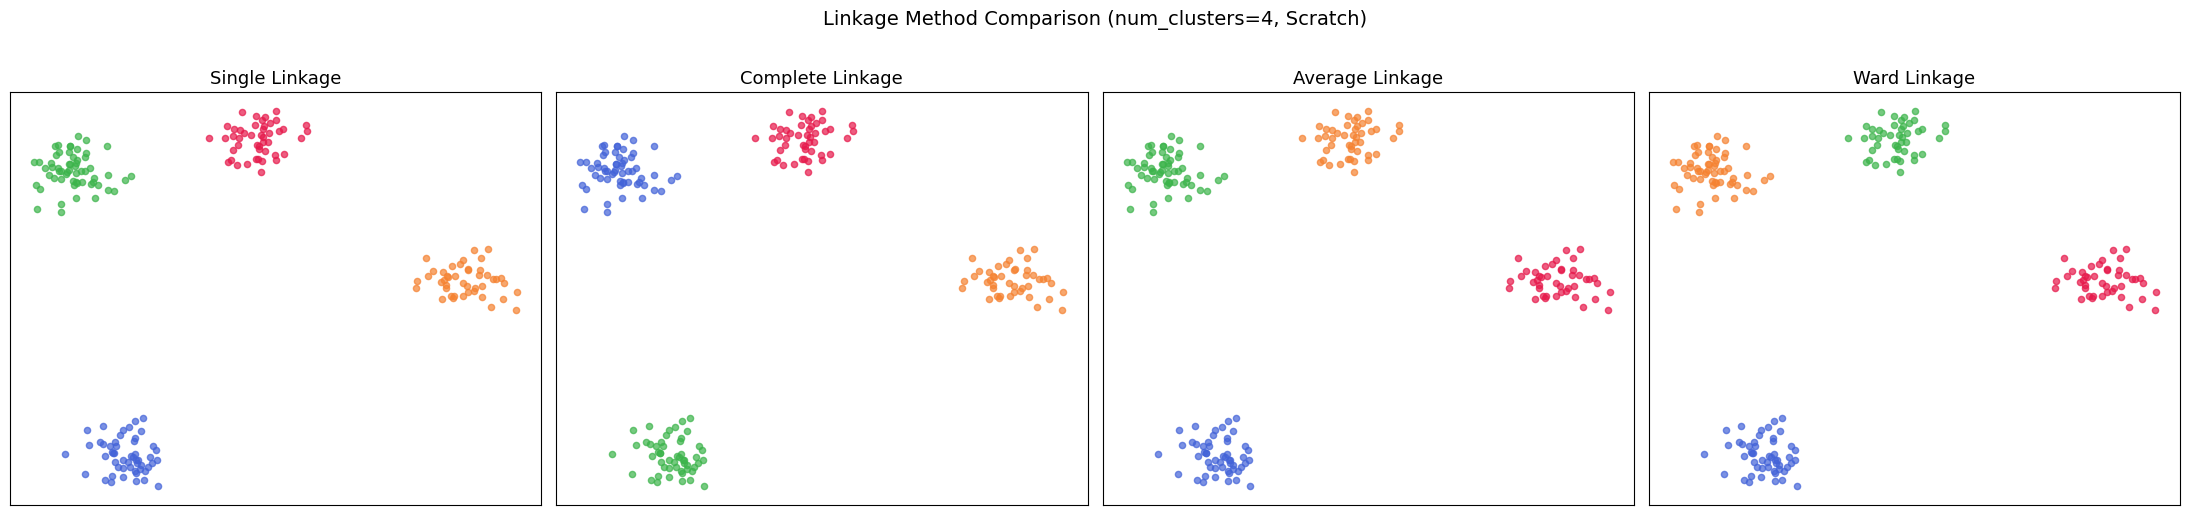

In [ ]:
# Compare all 4 linkage methods side by side
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, method in zip(axes, ["single", "complete", "average", "ward"]):
    agg = Agglomerative(num_clusters=4, linkage_method=method)
    agg.fit(X_agg)

    for j in range(4):
        mask = agg.labels == j
        ax.scatter(X_agg[mask, 0], X_agg[mask, 1], c=COLORS[j], s=20, alpha=0.7)
    ax.set_title(f"{method.capitalize()} Linkage", fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Linkage Method Comparison (num_clusters=4, Scratch)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

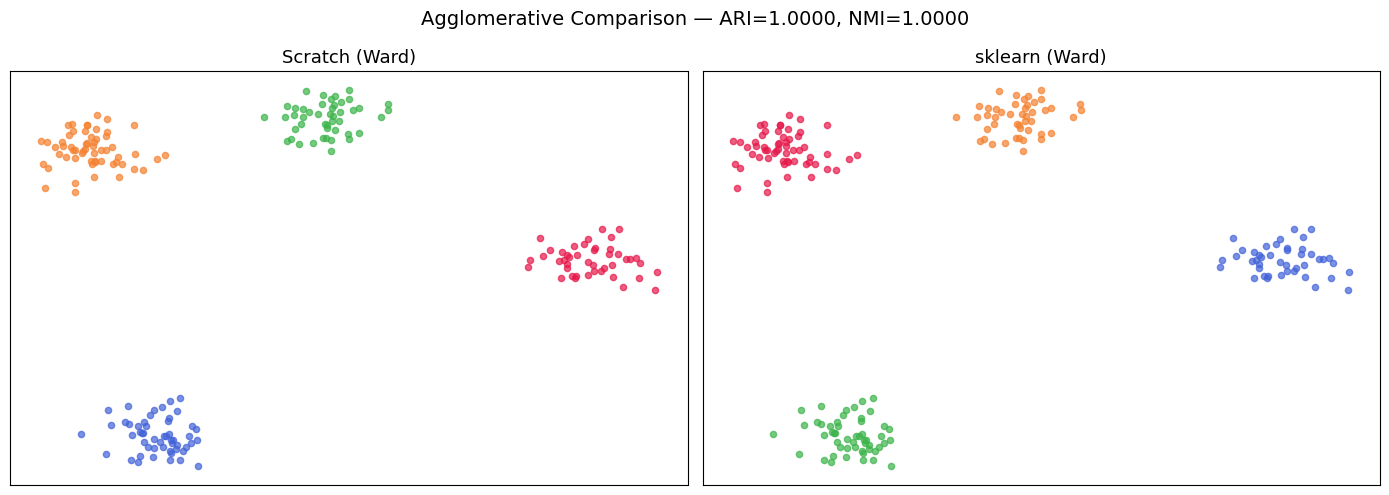

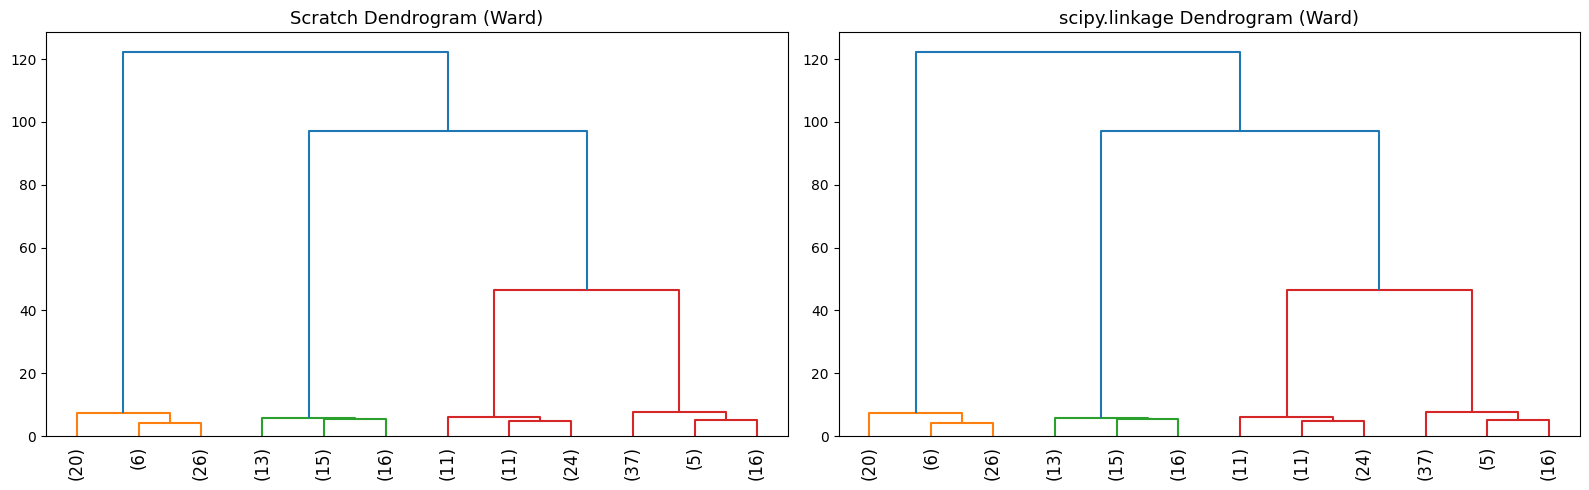

Adjusted Rand Index (scratch vs sklearn): 1.0000
Normalized Mutual Information: 1.0000


In [ ]:
# Compare scratch vs sklearn AgglomerativeClustering (Ward)
from sklearn.cluster import AgglomerativeClustering as SklearnAgg

agg_scratch_w = Agglomerative(num_clusters=4, linkage_method="ward")
agg_scratch_w.fit(X_agg)

agg_sk = SklearnAgg(n_clusters=4, linkage="ward")
agg_sk.fit(X_agg)

ari = adjusted_rand_score(agg_scratch_w.labels, agg_sk.labels_)
nmi = normalized_mutual_info_score(agg_scratch_w.labels, agg_sk.labels_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j in range(4):
    mask = agg_scratch_w.labels == j
    axes[0].scatter(X_agg[mask, 0], X_agg[mask, 1], c=COLORS[j], s=20, alpha=0.7)
axes[0].set_title("Scratch (Ward)", fontsize=13)

for j in range(4):
    mask = agg_sk.labels_ == j
    axes[1].scatter(X_agg[mask, 0], X_agg[mask, 1], c=COLORS[j], s=20, alpha=0.7)
axes[1].set_title("sklearn (Ward)", fontsize=13)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(f"Agglomerative Comparison — ARI={ari:.4f}, NMI={nmi:.4f}", fontsize=14)
plt.tight_layout()
plt.show()

# Also compare scipy's linkage on the same data
Z_scipy = linkage(X_agg, method="ward")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dendrogram(agg_scratch_w.linkage_matrix, ax=axes[0], truncate_mode="lastp", p=12, leaf_rotation=90)
axes[0].set_title("Scratch Dendrogram (Ward)", fontsize=13)

dendrogram(Z_scipy, ax=axes[1], truncate_mode="lastp", p=12, leaf_rotation=90)
axes[1].set_title("scipy.linkage Dendrogram (Ward)", fontsize=13)

plt.tight_layout()
plt.show()

print(f"Adjusted Rand Index (scratch vs sklearn): {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")

---
# 4) Mean Shift Clustering

Mean Shift is a **mode-seeking** algorithm based on **kernel density estimation (KDE)**. It iteratively shifts each point towards the region of highest local density — the modes of the underlying probability density function. Clusters are the basins of attraction of these modes.

**When to use:** The number of clusters is unknown, clusters may be non-spherical, and you need a non-parametric density-based method.

```
MeanShift(X, bandwidth, tol, max_iter):
    Initialize shifted_points = X.copy()
    for each iteration t:
        for each point x in shifted_points:
            Compute Gaussian kernel weights to all data points
            x_new = weighted mean of X using kernel weights
            x = x_new
        if max shift < tol: break
    Identify unique modes by merging nearby converged points
    Assign labels based on nearest mode
```

| Pros | Cons |
|------|------|
| No need to specify $k$ | $O(n^2)$ per iteration |
| Finds arbitrary-shape clusters | Bandwidth selection is critical |
| Non-parametric, principled (KDE) | Computationally expensive |
| Guaranteed convergence (Gaussian kernel) | Poor in high dimensions |

In [ ]:
class MeanShiftScratch:
    """Mean Shift clustering using Gaussian kernel.

    Iteratively shifts each point to the weighted mean of its neighborhood,
    converging to local density maxima (modes).
    """

    def __init__(self, bandwidth=1.0, max_iter=300, tol=1e-5, merge_tol=None):
        self.bandwidth = bandwidth
        self.max_iter = max_iter
        self.tol = tol
        self.merge_tol = merge_tol if merge_tol is not None else bandwidth * 0.5
        self.cluster_centers_ = None
        self.labels = None
        self.n_iter_ = 0

    def _gaussian_kernel(self, distances):
        """Compute Gaussian kernel weights from squared distances."""
        # (num_points,) or (num_points, num_samples)
        return np.exp(-0.5 * (distances / self.bandwidth) ** 2)

    def fit(self, X):
        num_samples, num_features = X.shape

        # (num_samples, num_features) — each point starts at its original location
        shifted = X.copy()

        for iteration in range(self.max_iter):
            new_shifted = np.empty_like(shifted)

            for i in range(num_samples):
                # (num_samples,) — distance from shifted[i] to all original points
                dists = np.linalg.norm(X - shifted[i], axis=1)

                # (num_samples,) — Gaussian weights
                weights = self._gaussian_kernel(dists)

                # Weighted mean: (num_samples, 1) * (num_samples, num_features) → (num_features,)
                new_shifted[i] = (weights[:, np.newaxis] * X).sum(axis=0) / weights.sum()

            # Convergence: maximum point displacement
            max_shift = np.max(np.linalg.norm(new_shifted - shifted, axis=1))
            shifted = new_shifted
            self.n_iter_ = iteration + 1

            if max_shift < self.tol:
                break

        # Merge nearby converged points into cluster centers
        self.cluster_centers_ = self._merge_modes(shifted)

        # Assign each original point to the nearest cluster center
        # (num_samples, num_centers)
        dists_to_centers = np.linalg.norm(
            X[:, np.newaxis, :] - self.cluster_centers_[np.newaxis, :, :], axis=2
        )
        # (num_samples,)
        self.labels = np.argmin(dists_to_centers, axis=1)

        return self

    def _merge_modes(self, shifted):
        """Merge converged points that are within merge_tol of each other."""
        modes = []
        for point in shifted:
            merged = False
            for idx, mode in enumerate(modes):
                if np.linalg.norm(point - mode) < self.merge_tol:
                    merged = True
                    break
            if not merged:
                modes.append(point.copy())

        # (num_clusters, num_features)
        return np.array(modes)


print("MeanShiftScratch class defined.")

MeanShiftScratch class defined.


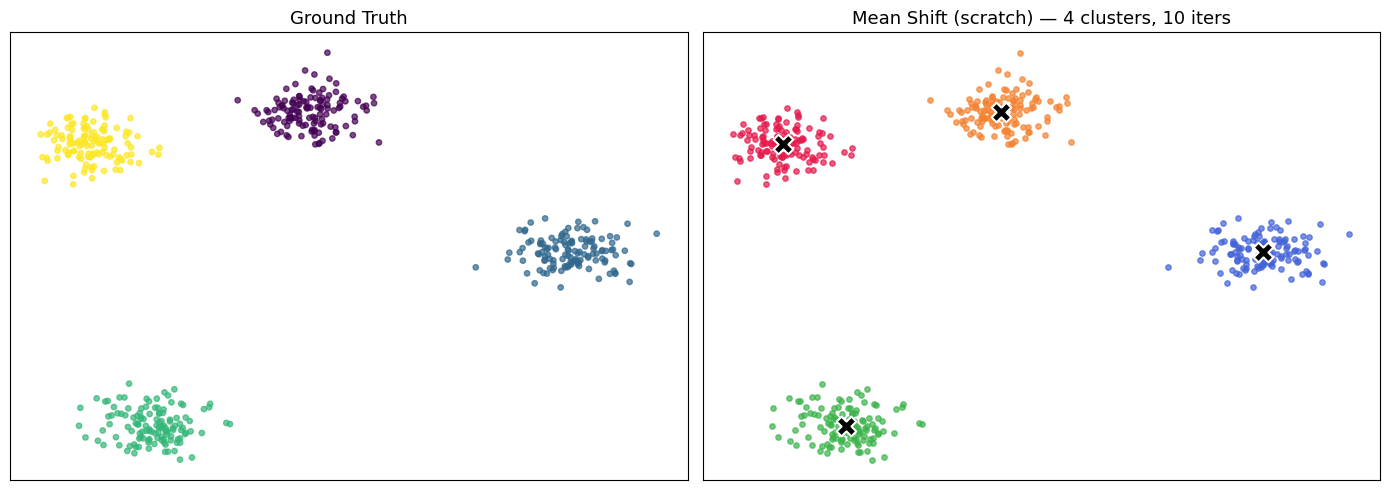

In [ ]:
# Demonstrate Mean Shift on blobs
ms_scratch = MeanShiftScratch(bandwidth=1.5, max_iter=100, tol=1e-5)
ms_scratch.fit(X_blobs)

num_clusters_found = len(ms_scratch.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap="viridis", s=15, alpha=0.7)
axes[0].set_title("Ground Truth", fontsize=13)

for j in range(num_clusters_found):
    mask = ms_scratch.labels == j
    axes[1].scatter(
        X_blobs[mask, 0], X_blobs[mask, 1],
        c=COLORS[j % len(COLORS)], s=15, alpha=0.7,
    )
axes[1].scatter(
    ms_scratch.cluster_centers_[:, 0], ms_scratch.cluster_centers_[:, 1],
    c="black", marker="X", s=200, edgecolors="white", linewidths=1.5, zorder=5,
)
axes[1].set_title(
    f"Mean Shift (scratch) — {num_clusters_found} clusters, {ms_scratch.n_iter_} iters",
    fontsize=13,
)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

**Impact of Bandwidth**

The bandwidth $h$ is the most critical parameter:
- **Too small** → many spurious clusters (over-segmentation)
- **Too large** → all points merge into one cluster (under-segmentation)

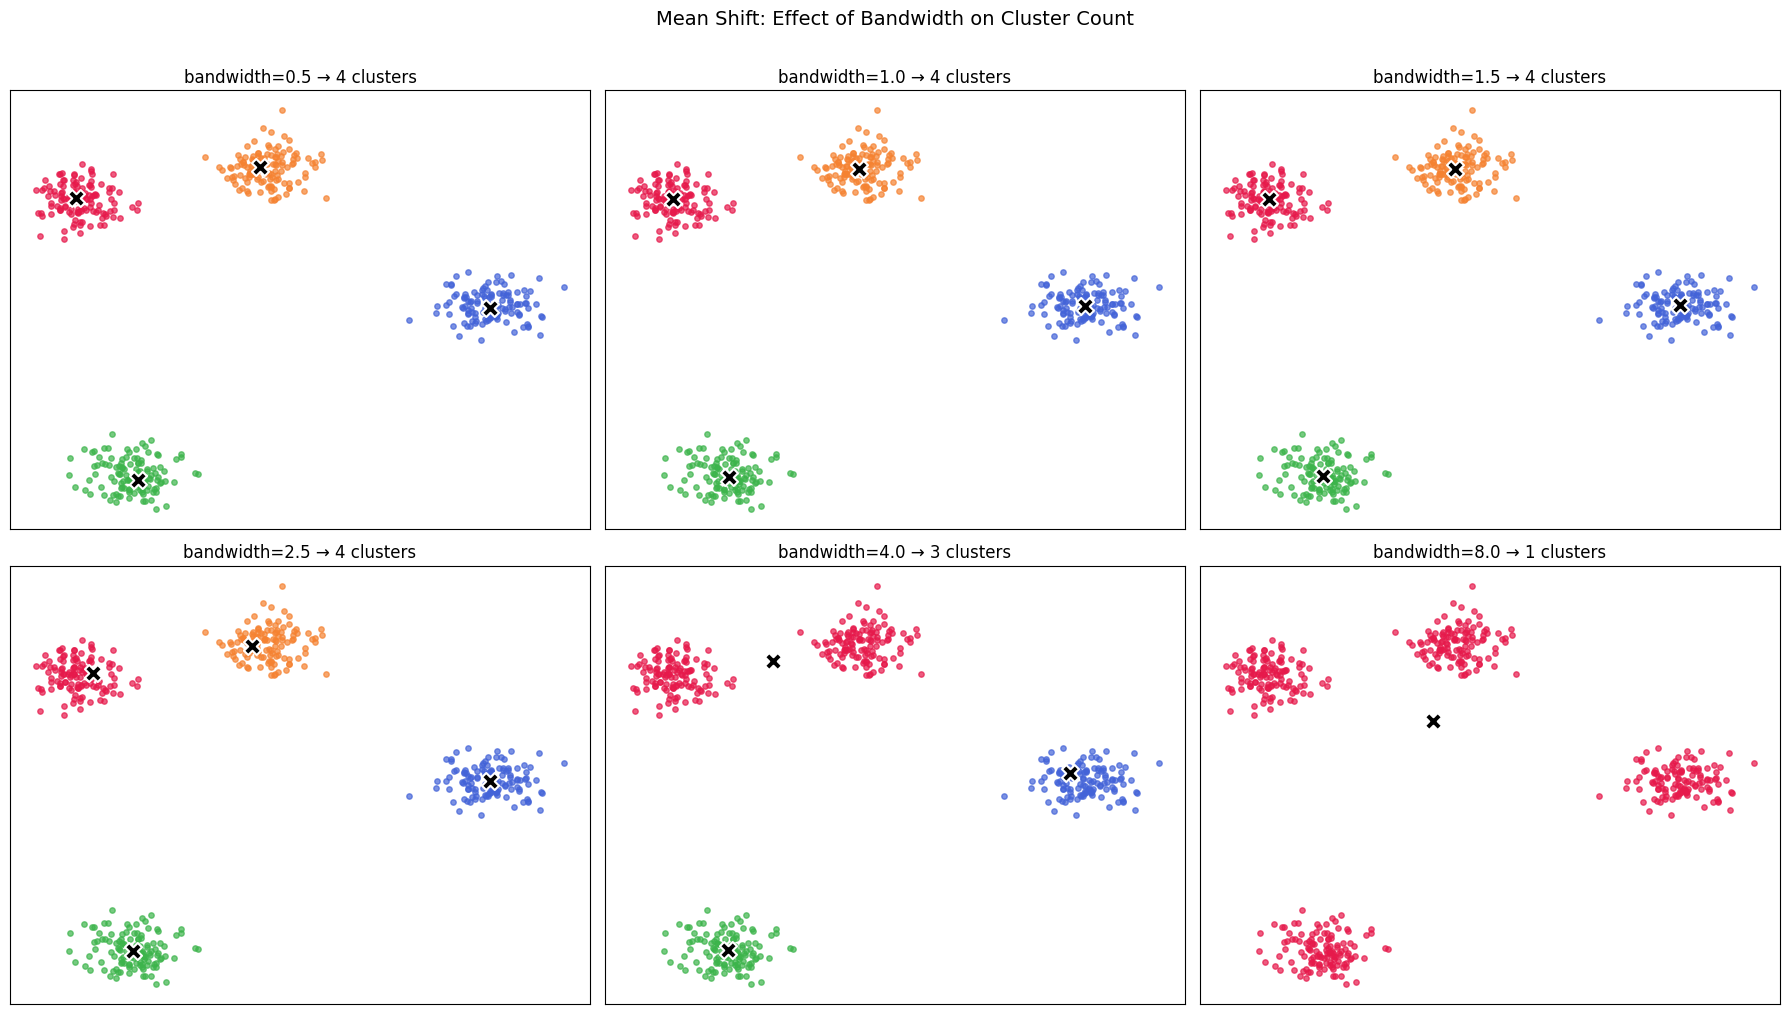

In [ ]:
# Demonstrate bandwidth impact
bandwidths = [0.5, 1.0, 1.5, 2.5, 4.0, 8.0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, bw in zip(axes.flat, bandwidths):
    ms = MeanShiftScratch(bandwidth=bw, max_iter=100, tol=1e-4)
    ms.fit(X_blobs)
    num_found = len(ms.cluster_centers_)

    for j in range(num_found):
        mask = ms.labels == j
        ax.scatter(
            X_blobs[mask, 0], X_blobs[mask, 1],
            c=COLORS[j % len(COLORS)], s=15, alpha=0.7,
        )
    ax.scatter(
        ms.cluster_centers_[:, 0], ms.cluster_centers_[:, 1],
        c="black", marker="X", s=150, edgecolors="white", linewidths=1.5, zorder=5,
    )
    ax.set_title(f"bandwidth={bw} → {num_found} clusters", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Mean Shift: Effect of Bandwidth on Cluster Count", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
def estimate_bandwidth_silverman(X):
    """Silverman's rule of thumb for Gaussian KDE bandwidth."""
    num_samples, num_features = X.shape
    sigma = np.mean(np.std(X, axis=0))
    return (4.0 / ((num_features + 2) * num_samples)) ** (1.0 / (num_features + 4)) * sigma


bw_est = estimate_bandwidth_silverman(X_blobs)
print(f"Silverman bandwidth estimate for blobs: {bw_est:.4f}")

ms_auto = MeanShiftScratch(bandwidth=bw_est, max_iter=100, tol=1e-4)
ms_auto.fit(X_blobs)
print(f"Clusters found with Silverman bandwidth: {len(ms_auto.cluster_centers_)}")

Silverman bandwidth estimate for blobs: 2.0455
Clusters found with Silverman bandwidth: 4


sklearn estimated bandwidth: 1.9068


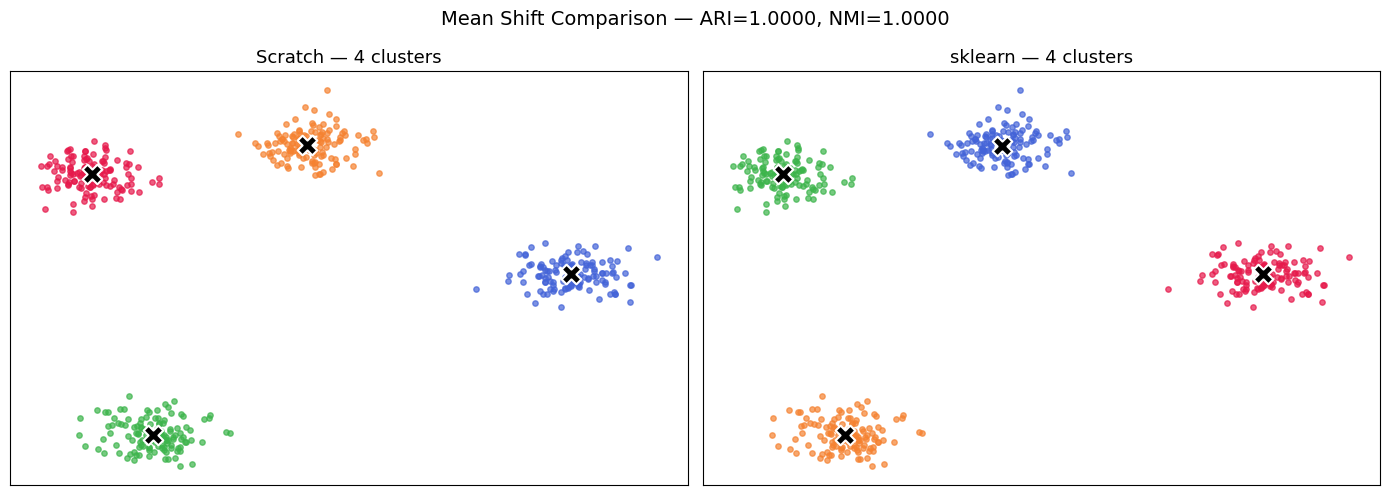

Scratch iterations: 10
Adjusted Rand Index: 1.0000
Normalized Mutual Information: 1.0000


In [ ]:
# Compare scratch vs sklearn Mean Shift
from sklearn.cluster import MeanShift as SklearnMS
from sklearn.cluster import estimate_bandwidth

bw = estimate_bandwidth(X_blobs, quantile=0.2)
print(f"sklearn estimated bandwidth: {bw:.4f}")

ms_ours = MeanShiftScratch(bandwidth=bw, max_iter=200, tol=1e-5)
ms_ours.fit(X_blobs)

ms_sk = SklearnMS(bandwidth=bw)
ms_sk.fit(X_blobs)

ari = adjusted_rand_score(ms_ours.labels, ms_sk.labels_)
nmi = normalized_mutual_info_score(ms_ours.labels, ms_sk.labels_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

num_ours = len(ms_ours.cluster_centers_)
for j in range(num_ours):
    mask = ms_ours.labels == j
    axes[0].scatter(X_blobs[mask, 0], X_blobs[mask, 1], c=COLORS[j % len(COLORS)], s=15, alpha=0.7)
axes[0].scatter(
    ms_ours.cluster_centers_[:, 0], ms_ours.cluster_centers_[:, 1],
    c="black", marker="X", s=200, edgecolors="white", linewidths=1.5, zorder=5,
)
axes[0].set_title(f"Scratch — {num_ours} clusters", fontsize=13)

num_sk = len(ms_sk.cluster_centers_)
for j in range(num_sk):
    mask = ms_sk.labels_ == j
    axes[1].scatter(X_blobs[mask, 0], X_blobs[mask, 1], c=COLORS[j % len(COLORS)], s=15, alpha=0.7)
axes[1].scatter(
    ms_sk.cluster_centers_[:, 0], ms_sk.cluster_centers_[:, 1],
    c="black", marker="X", s=200, edgecolors="white", linewidths=1.5, zorder=5,
)
axes[1].set_title(f"sklearn — {num_sk} clusters", fontsize=13)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(f"Mean Shift Comparison — ARI={ari:.4f}, NMI={nmi:.4f}", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Scratch iterations: {ms_ours.n_iter_}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")

---
# 5) Comparison

In [ ]:
def run_all_methods(X, true_k=None):
    """Run all 4 clustering methods on dataset X and return labels dict."""
    results = {}

    # K-Means: use true_k if known, else 3
    k = true_k if true_k else 3
    km = KMeans(num_clusters=k, init="kmeans++", random_state=42)
    km.fit(X)
    results["K-Means"] = km.labels

    # DBSCAN: auto-select eps via k-distance heuristic
    dist_mat = squareform(pdist(X))
    # (num_samples,) — 5th nearest neighbor distance
    k_dists = np.sort(dist_mat, axis=1)[:, 5]
    eps_auto = np.percentile(k_dists, 90)
    db = DBSCAN(eps=eps_auto, min_samples=5)
    db.fit(X)
    results["DBSCAN"] = db.labels

    # Agglomerative: subsample for speed if needed
    n = min(len(X), 300)
    indices = np.random.RandomState(42).choice(len(X), n, replace=False)
    X_sub = X[indices]
    agg = Agglomerative(num_clusters=k, linkage_method="ward")
    agg.fit(X_sub)
    # Assign full dataset via nearest centroid of each cluster
    centroids_agg = np.array([
        X_sub[agg.labels == j].mean(axis=0)
        for j in range(k)
        if np.any(agg.labels == j)
    ])
    # (num_samples, num_agg_clusters)
    full_dists = np.linalg.norm(
        X[:, np.newaxis, :] - centroids_agg[np.newaxis, :, :], axis=2
    )
    results["Agglomerative"] = np.argmin(full_dists, axis=1)

    # Mean Shift: auto bandwidth
    bw = estimate_bandwidth_silverman(X) * 2.0
    ms = MeanShiftScratch(bandwidth=max(bw, 0.3), max_iter=100, tol=1e-4)
    ms.fit(X)
    results["Mean Shift"] = ms.labels

    return results


print("run_all_methods helper defined.")

run_all_methods helper defined.


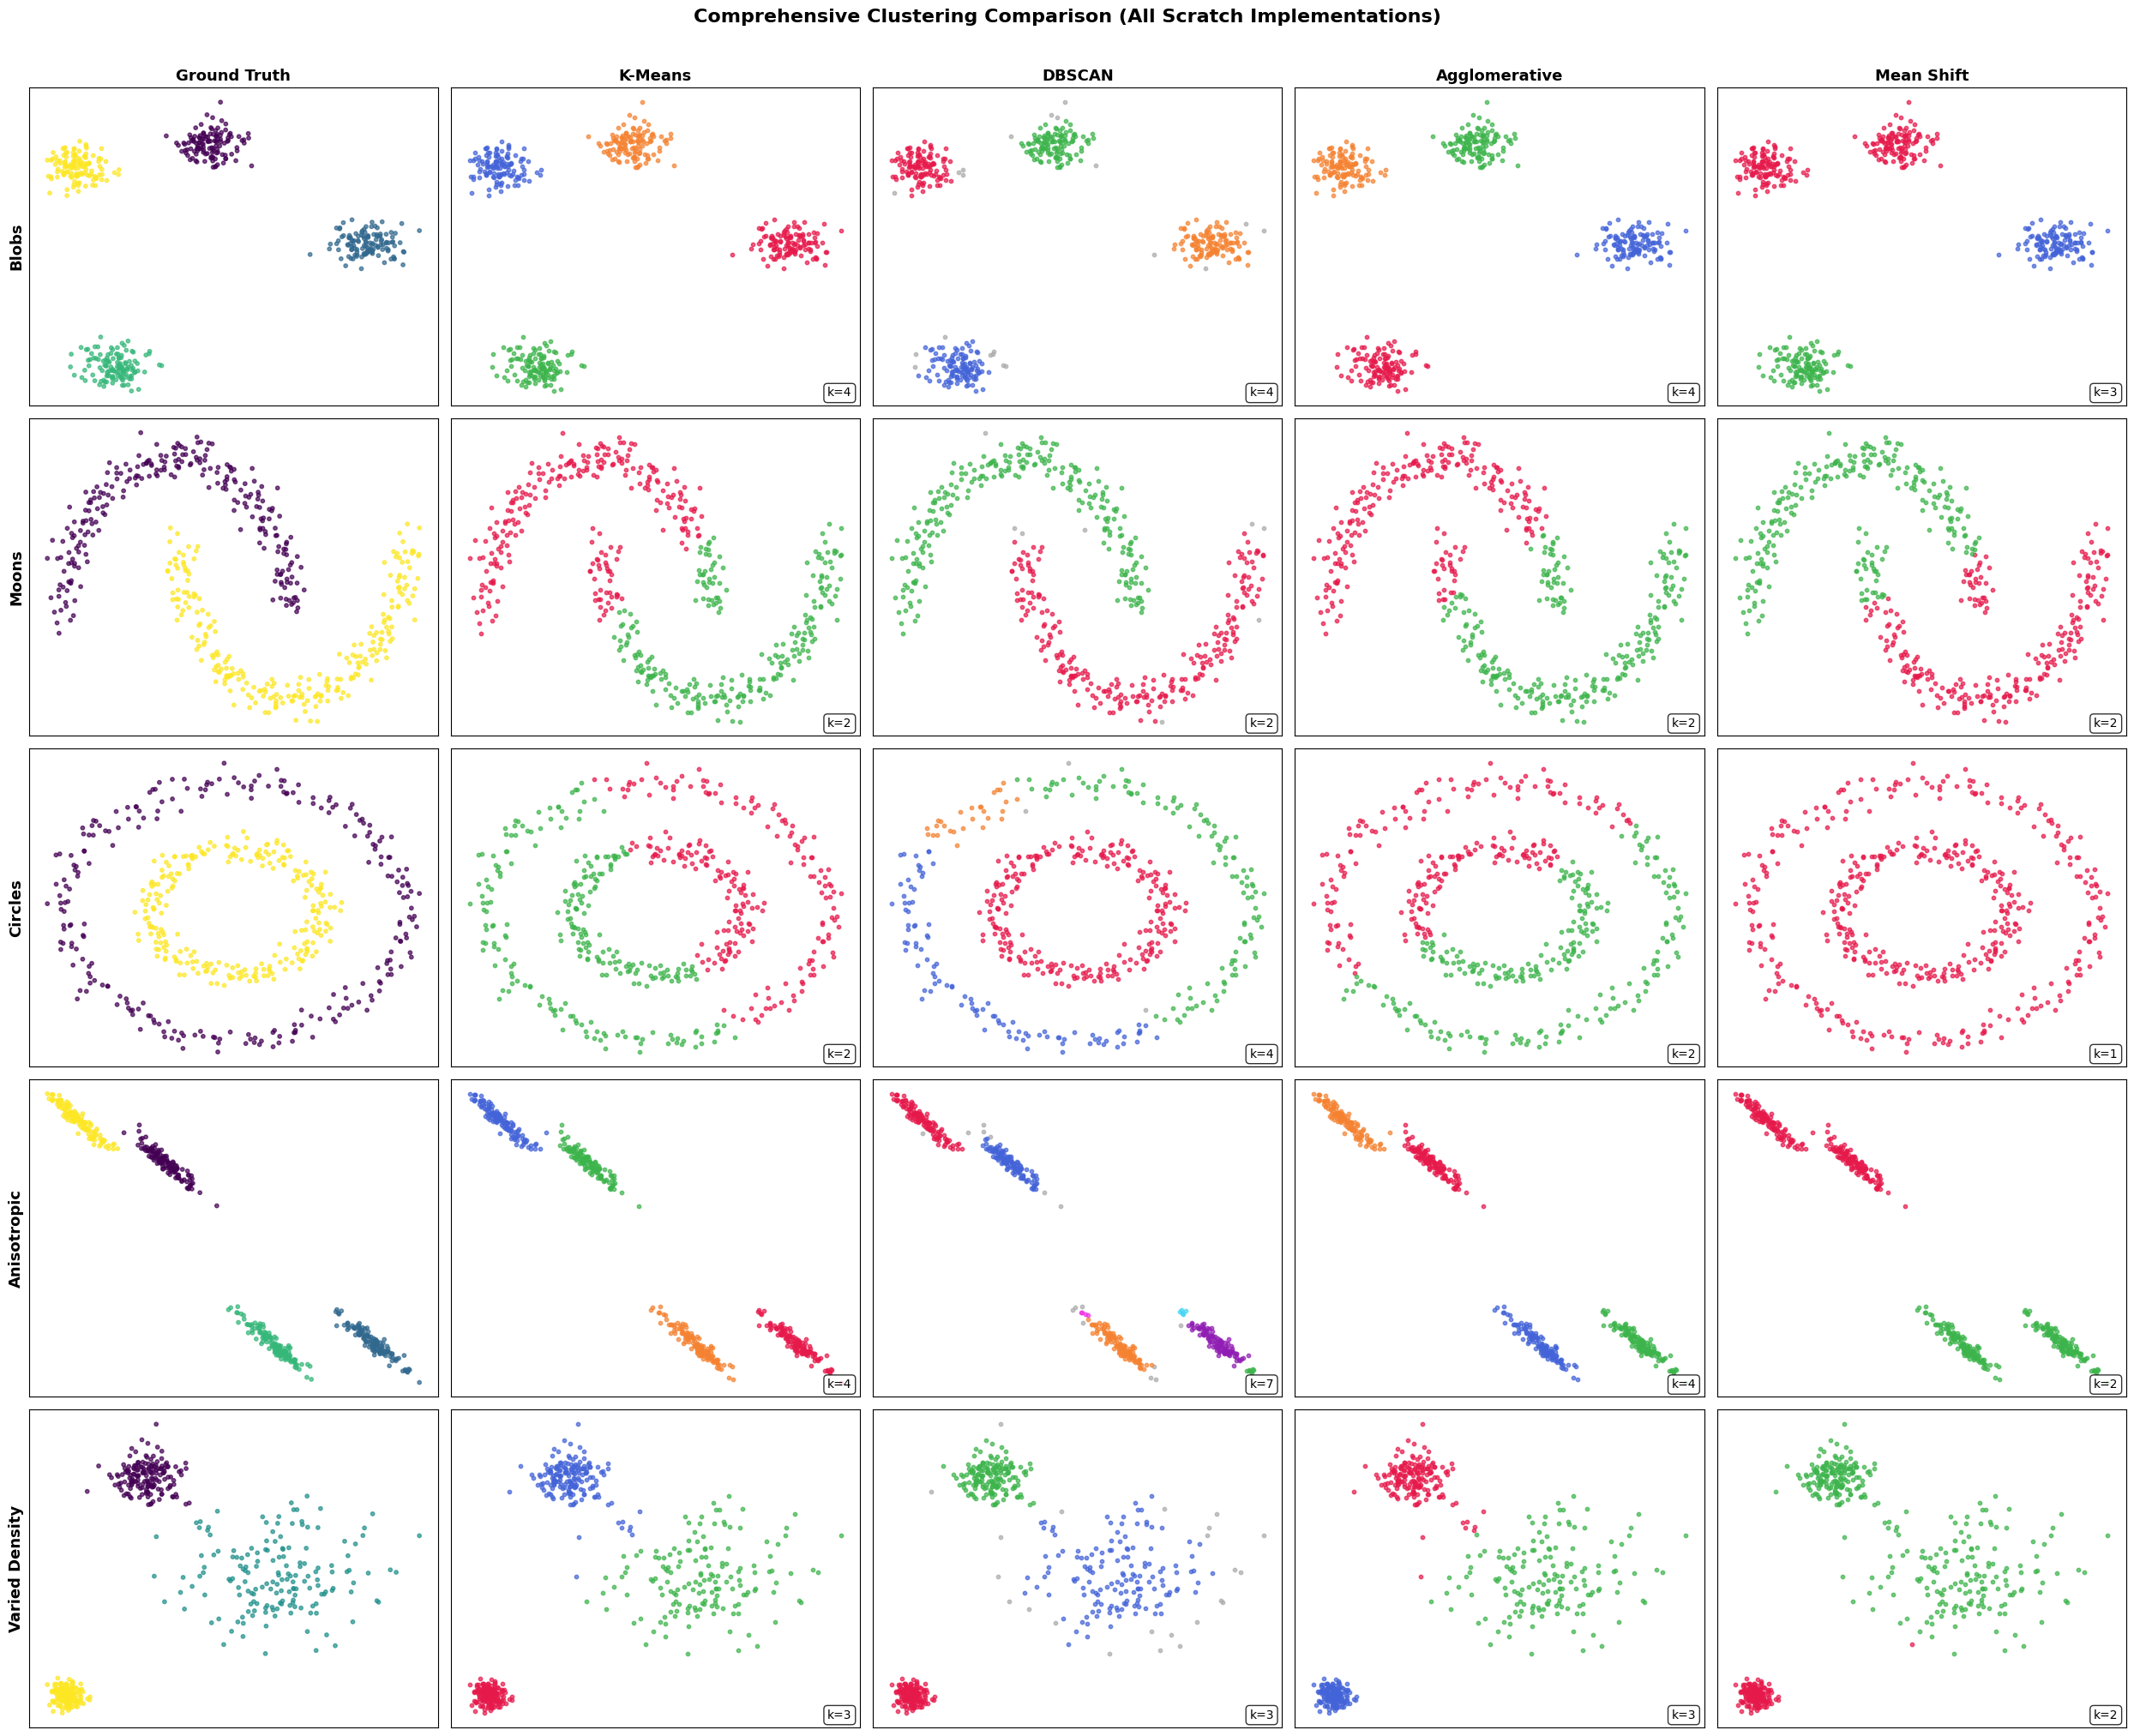

In [ ]:
# Grand comparison grid: rows = datasets, columns = methods
dataset_names = list(ALL_DATASETS.keys())
method_names = ["Ground Truth", "K-Means", "DBSCAN", "Agglomerative", "Mean Shift"]
true_k_map = {"Blobs": 4, "Moons": 2, "Circles": 2, "Anisotropic": 4, "Varied Density": 3}

fig, axes = plt.subplots(
    len(dataset_names), len(method_names),
    figsize=(5 * len(method_names), 4 * len(dataset_names)),
)

for row, dname in enumerate(dataset_names):
    X, y = ALL_DATASETS[dname]

    # Scale for consistent DBSCAN/Mean Shift behavior
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    results = run_all_methods(X_scaled, true_k=true_k_map.get(dname))

    # Ground truth column
    axes[row, 0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap="viridis", s=10, alpha=0.7)
    if row == 0:
        axes[row, 0].set_title("Ground Truth", fontsize=13, fontweight="bold")
    axes[row, 0].set_ylabel(dname, fontsize=13, fontweight="bold")

    # Method columns
    for col, mname in enumerate(["K-Means", "DBSCAN", "Agglomerative", "Mean Shift"]):
        ax = axes[row, col + 1]
        labels = results[mname]
        unique = set(labels)

        for label in sorted(unique):
            mask = labels == label
            c = NOISE_COLOR if label == -1 else COLORS[label % len(COLORS)]
            ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], c=c, s=10, alpha=0.7)

        n_clusters = len(unique - {-1})
        if row == 0:
            ax.set_title(mname, fontsize=13, fontweight="bold")

        # Show cluster count in corner
        ax.text(
            0.98, 0.02, f"k={n_clusters}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )

    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle(
    "Comprehensive Clustering Comparison (All Scratch Implementations)",
    fontsize=16, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# Summary

| Property | K-Means | DBSCAN | Agglomerative | Mean Shift |
|---|---|---|---|---|
| **Cluster shape** | Convex / spherical | Arbitrary | Depends on linkage | Arbitrary |
| **Requires k** | Yes | No | Yes (or cut height) | No |
| **Key parameters** | k | eps, min_samples | k, linkage | bandwidth |
| **Handles noise** | No | Yes (labels noise) | No | No |
| **Time complexity** | $O(nkdT)$ | $O(n^2)$ | $O(n^2 \log n)$ to $O(n^3)$ | $O(Tn^2d)$ |
| **Space complexity** | $O(nk)$ | $O(n^2)$ | $O(n^2)$ | $O(n^2)$ |
| **Deterministic** | No (init-dependent) | Yes | Yes | Yes (given bandwidth) |
| **Scalability** | Excellent | Moderate | Poor (large n) | Poor (large n) |
| **Best for** | Large, spherical | Arbitrary + noise | Hierarchy needed | Unknown k, modes |

### Key Takeaways

1. **No single algorithm dominates** — the best choice depends on cluster geometry, noise, and scale.
2. **K-Means** is the fastest and simplest, but its Voronoi partitioning fails on non-convex shapes.
3. **DBSCAN** excels on non-convex clusters with noise, but struggles with varying density.
4. **Agglomerative clustering** provides interpretable hierarchies but scales poorly.
5. **Mean Shift** is elegant and parameter-light (only bandwidth), but computationally expensive.
6. **Initialization matters:** K-Means++ provides provably better initialization than random.
7. **Parameter selection** (k, eps, bandwidth) is often the hardest practical challenge — use the elbow method, k-distance plots, and Silverman's rule as starting points.